# Supplementation-Aware Split Distribution Check

This notebook complements the original split-distribution EDA instead of replacing it.

Use it when the small-dataset workflow may include supplementation from `extra_samples_for_small_dataset.json` and the `load_extra_samples_for_small_dataset_splits.py` loader.

To reduce confusion, the simulated projected dataset view is hidden in this version of the notebook.

It now answers three practical questions:

1. What does the official exact FMA-small split look like?
2. What do the current processed `train_small`, `val_small`, and `test_small` parquet files contain right now?
3. What extra samples are currently present in the supplementation payload and where do they come from?

This notebook is intentionally small-dataset specific. The existing notebook remains the generic split-shape sanity check.

In [ ]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'MelCNN-MGR').exists() and (candidate / 'FMA').exists():
            return candidate
    raise FileNotFoundError('Could not locate workspace root containing MelCNN-MGR and FMA')


WORKSPACE_ROOT = find_workspace_root(Path.cwd())
TRACKS_CSV = WORKSPACE_ROOT / 'FMA' / 'fma_metadata' / 'tracks.csv'
PROCESSED_DIR = WORKSPACE_ROOT / 'MelCNN-MGR' / 'data' / 'processed'
SETTINGS_PATH = WORKSPACE_ROOT / 'MelCNN-MGR' / 'settings.json'
EXTRA_SAMPLES_PATH = PROCESSED_DIR / 'extra_samples_for_small_dataset.json'

TARGET_SUBSET = 'small'
SPLIT_ORDER = ['training', 'validation', 'test']
SPLIT_FILES = {
    'training': f'train_{TARGET_SUBSET}.parquet',
    'validation': f'val_{TARGET_SUBSET}.parquet',
    'test': f'test_{TARGET_SUBSET}.parquet',
}
TOP_N_GENRES = 12
BASE_RANDOM_SEED = 20260309

In [15]:
tracks = pd.read_csv(TRACKS_CSV, header=[0, 1], index_col=0)

official_mask = (
    (tracks[('set', 'subset')] == TARGET_SUBSET)
    & tracks[('track', 'genre_top')].notna()
    & tracks[('set', 'split')].isin(SPLIT_ORDER)
)
official_df = tracks.loc[official_mask, [('set', 'split'), ('track', 'genre_top')]].copy()
official_df.columns = ['split', 'genre_top']
official_df['source'] = 'fma'
official_df['sample_id'] = official_df.index.map(lambda track_id: f'fma:{int(track_id)}')
official_df.index.name = 'track_id'

processed_frames = []
for split_name, filename in SPLIT_FILES.items():
    split_path = PROCESSED_DIR / filename
    frame = pd.read_parquet(split_path).copy()
    frame['split'] = split_name
    frame.index.name = 'track_id'
    processed_frames.append(frame)
processed_df = pd.concat(processed_frames, axis=0)

settings_payload = json.loads(SETTINGS_PATH.read_text())
supplementation_settings = settings_payload['small_dataset_supplementation']
target_genres = supplementation_settings['target_genres']
n_extra_expected = int(supplementation_settings['n_extra_expected'])
train_ratio = float(supplementation_settings['train_n_val_test_split_ratio'])

extra_samples_payload = json.loads(EXTRA_SAMPLES_PATH.read_text())
selected_tracks = extra_samples_payload.get('selected_tracks', {})

print(f'Workspace root              : {WORKSPACE_ROOT}')
print(f'Official exact-small rows   : {len(official_df):,}')
print(f'Current processed split rows: {len(processed_df):,}')
print(f'Target genres in settings   : {target_genres}')
print(f'n_extra_expected per genre  : {n_extra_expected}')
print(f'train split ratio           : {train_ratio:.2f}')
print(f'Genres with selected payload: {sorted(selected_tracks)}')

Workspace root              : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Official exact-small rows   : 8,000
Current processed split rows: 10,694
Target genres in settings   : ['Hip-Hop', 'Pop', 'Folk', 'Rock', 'Electronic', 'Classical', 'Jazz', 'Country', 'Blues']
n_extra_expected per genre  : 300
train split ratio           : 0.80
Genres with selected payload: ['Blues', 'Classical', 'Country', 'Electronic', 'Folk', 'Hip-Hop', 'Jazz', 'Pop', 'Rock']


In [16]:
def stable_row_key(row: dict[str, object]) -> str:
    track_id = row.get('track_id')
    filepath = row.get('filepath') or row.get('relative_path') or row.get('filename') or ''
    return '|'.join([
        str(row.get('source') or ''),
        str(row.get('genre') or ''),
        '' if track_id is None else str(track_id),
        str(filepath),
    ])


def genre_seed(base_seed: int, genre: str) -> int:
    digest = hashlib.sha1(genre.encode('utf-8')).digest()
    genre_hash = int.from_bytes(digest[:4], byteorder='big', signed=False)
    return base_seed + genre_hash


def deterministic_shuffle(rows: list[dict[str, object]], seed: int, genre: str) -> list[dict[str, object]]:
    shuffled = list(rows)
    shuffled.sort(key=stable_row_key)
    random.Random(genre_seed(seed, genre)).shuffle(shuffled)
    return shuffled


def compute_split_counts(total: int, train_ratio: float) -> dict[str, int]:
    train_count = int(round(total * train_ratio))
    train_count = max(0, min(total, train_count))

    remainder = total - train_count
    if remainder % 2 == 1:
        train_count += 1
        remainder -= 1

    val_count = remainder // 2
    test_count = remainder // 2
    return {
        'training': train_count,
        'validation': val_count,
        'test': test_count,
    }


def counts_by_genre_and_split(frame: pd.DataFrame) -> pd.DataFrame:
    table = pd.crosstab(frame['genre_top'], frame['split'])
    return table.reindex(columns=SPLIT_ORDER, fill_value=0).sort_index()


def proportions_from_counts(counts: pd.DataFrame) -> pd.DataFrame:
    return counts.div(counts.sum(axis=0), axis=1).fillna(0.0)


def tvd(p: np.ndarray, q: np.ndarray) -> float:
    return 0.5 * np.abs(p - q).sum()


def jsd(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    q = np.clip(q, eps, 1.0)
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log2(p / m)) + np.sum(q * np.log2(q / m)))


def split_distance_metrics(counts: pd.DataFrame) -> dict[str, float]:
    props = proportions_from_counts(counts)
    genres = props.index
    p_train = props['training'].reindex(genres).to_numpy()
    p_val = props['validation'].reindex(genres).to_numpy()
    p_test = props['test'].reindex(genres).to_numpy()
    return {
        'TVD(train,val)': tvd(p_train, p_val),
        'TVD(train,test)': tvd(p_train, p_test),
        'JSD(train,val)': jsd(p_train, p_val),
        'JSD(train,test)': jsd(p_train, p_test),
    }

In [17]:
official_counts = counts_by_genre_and_split(official_df)
processed_counts = counts_by_genre_and_split(processed_df)

official_split_sizes = official_df['split'].value_counts().reindex(SPLIT_ORDER, fill_value=0)
processed_split_sizes = processed_df['split'].value_counts().reindex(SPLIT_ORDER, fill_value=0)
split_size_compare = pd.concat(
    [
        official_split_sizes.rename('official_exact_small'),
        processed_split_sizes.rename('processed_current'),
    ],
    axis=1,
)
split_size_compare['delta_vs_official'] = split_size_compare['processed_current'] - split_size_compare['official_exact_small']

processed_source_summary = (
    processed_df.groupby(['split', 'source']).size().unstack(fill_value=0).reindex(SPLIT_ORDER, fill_value=0)
)

current_has_non_fma_rows = 'source' in processed_df.columns and processed_df['source'].ne('fma').any()
new_genres_vs_official = sorted(set(processed_counts.index) - set(official_counts.index))

print('Current split-size comparison:')
display(split_size_compare)

print('Current processed source mix by split:')
display(processed_source_summary)

print(f'Non-FMA rows already present? {current_has_non_fma_rows}')
print(f'Genres outside official exact-small currently present: {new_genres_vs_official}')

print('Official exact-small genre counts:')
display(official_counts)

print('Current processed genre counts:')
display(processed_counts)

Current split-size comparison:


,official_exact_small,processed_current,delta_vs_official
split,,,
training,6400,8556,2156
validation,800,1069,269
test,800,1069,269


Current processed source mix by split:


source,dortmund,fma,fma-medium,gtzan
split,,,,
training,284,6400,1790,82
validation,40,800,222,7
test,32,800,226,11


Non-FMA rows already present? True
Genres outside official exact-small currently present: ['Blues', 'Classical', 'Country', 'Jazz']
Official exact-small genre counts:


split,training,validation,test
genre_top,,,
Electronic,800,100,100
Experimental,800,100,100
Folk,800,100,100
Hip-Hop,800,100,100
Instrumental,800,100,100
International,800,100,100
Pop,800,100,100
Rock,800,100,100


Current processed genre counts:


split,training,validation,test
genre_top,,,
Blues,236,29,29
Classical,240,30,30
Country,240,30,30
Electronic,1040,130,130
Experimental,800,100,100
Folk,1040,130,130
Hip-Hop,1040,130,130
Instrumental,800,100,100
International,800,100,100


## Payload Allocation Note

In the next code cell, `allocation_records` means **payload rows currently selected from** `extra_samples_for_small_dataset.json` after the per-genre cap is applied.

It does **not** mean projected rows already written into the split parquet files, and it does **not** mean the simulated future dataset. In this simplified notebook version, the allocation cell is only being used to summarize the selected payload itself.

In [ ]:
allocation_records = []
allocation_summary_records = []

for genre in target_genres:
    genre_rows = list(selected_tracks.get(genre, []))[:n_extra_expected]
    shuffled_rows = deterministic_shuffle(genre_rows, BASE_RANDOM_SEED, genre)
    split_counts = compute_split_counts(len(shuffled_rows), train_ratio)

    for row in shuffled_rows:
        allocation_records.append({
            'genre_top': genre,
            'source': row.get('source', 'unknown'),
            'track_id': row.get('track_id'),
            'filepath': row.get('filepath'),
        })

    allocation_summary_records.append({
        'genre_top': genre,
        'selected_rows_used': len(shuffled_rows),
        'cap_per_genre': n_extra_expected,
        'train_would_get': split_counts['training'],
        'validation_would_get': split_counts['validation'],
        'test_would_get': split_counts['test'],
    })

allocation_df = pd.DataFrame(allocation_records)
allocation_summary = pd.DataFrame(allocation_summary_records).set_index('genre_top').sort_values('selected_rows_used', ascending=False)

print('Supplementation payload rows currently selected per target genre:')
display(allocation_summary)

if allocation_df.empty:
    payload_source_summary = pd.DataFrame()
    payload_genre_summary = pd.DataFrame()
    print('No selected supplementation rows were found in the payload.')
else:
    payload_source_summary = (
        allocation_df.groupby('source').size().rename('selected_rows').sort_values(ascending=False).to_frame()
    )
    payload_genre_summary = (
        allocation_df.groupby(['genre_top', 'source']).size().unstack(fill_value=0).sort_index()
    )

    print('Supplementation payload source mix:')
    display(payload_source_summary)

    print('Supplementation payload rows by genre and source:')
    display(payload_genre_summary)

Projected additions per target genre:


,selected_rows,train_add,val_add,test_add
genre_top,,,,
Hip-Hop,300,240,30,30
Pop,300,240,30,30
Folk,300,240,30,30
Rock,300,240,30,30
Electronic,300,240,30,30
Classical,300,240,30,30
Jazz,300,240,30,30
Country,300,240,30,30
Blues,294,236,29,29


Projected added rows by split and source:


source,dortmund,fma-medium,gtzan
split,,,
training,284,1790,82
validation,40,222,7
test,32,226,11


Projected total source mix after materializing the payload:


source,dortmund,fma,fma-medium,gtzan
split,,,,
training,568,6400,3580,164
validation,80,800,444,14
test,64,800,452,22


Projected split sizes after materializing the payload:


,processed_current,projected_after_payload,delta_added
split,,,
training,8556,10712,2156
validation,1069,1338,269
test,1069,1338,269


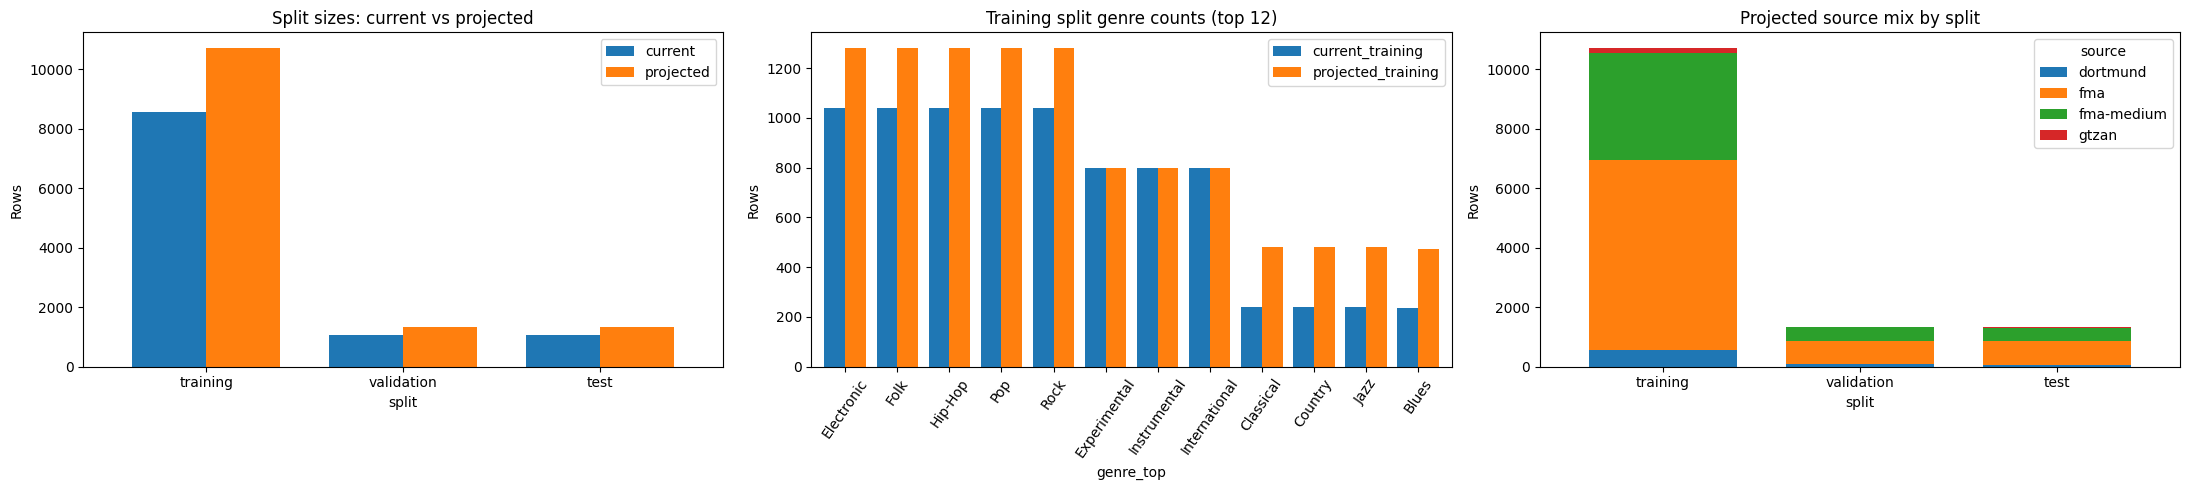

In [ ]:
current_split_sizes = processed_counts.sum(axis=0).reindex(SPLIT_ORDER)

current_training = processed_counts['training'].sort_values(ascending=False)
official_training = official_counts['training'].reindex(current_training.index.union(official_counts.index), fill_value=0)
plot_genres = (current_training.add(official_training, fill_value=0)
               .sort_values(ascending=False)
               .head(TOP_N_GENRES)
               .index)
training_compare = pd.DataFrame({
    'official_training': official_training.reindex(plot_genres, fill_value=0),
    'current_training': current_training.reindex(plot_genres, fill_value=0),
})

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

pd.DataFrame({
    'official': official_split_sizes,
    'current': current_split_sizes,
}).plot(kind='bar', ax=axes[0], width=0.75)
axes[0].set_title('Split sizes: official vs current')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=0)

training_compare.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title(f'Training split genre counts (top {TOP_N_GENRES})')
axes[1].set_ylabel('Rows')
axes[1].tick_params(axis='x', rotation=55)

processed_source_summary.plot(kind='bar', stacked=True, ax=axes[2], width=0.75)
axes[2].set_title('Current source mix by split')
axes[2].set_ylabel('Rows')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Split-distance metrics before and after materializing the current payload:


,"TVD(train,val)","TVD(train,test)","JSD(train,val)","JSD(train,test)"
official_exact_small,0.0000,0.0000,0.0,0.0
processed_current,0.0005,0.0005,0.0,0.0
projected_after_payload,0.0007,0.0007,0.0,0.0


Per-genre added counts implied by the current payload:


split,training,validation,test,total_added
genre_top,,,,
Classical,240,30,30,300
Country,240,30,30,300
Electronic,240,30,30,300
Folk,240,30,30,300
Hip-Hop,240,30,30,300
Jazz,240,30,30,300
Pop,240,30,30,300
Rock,240,30,30,300
Blues,236,29,29,294


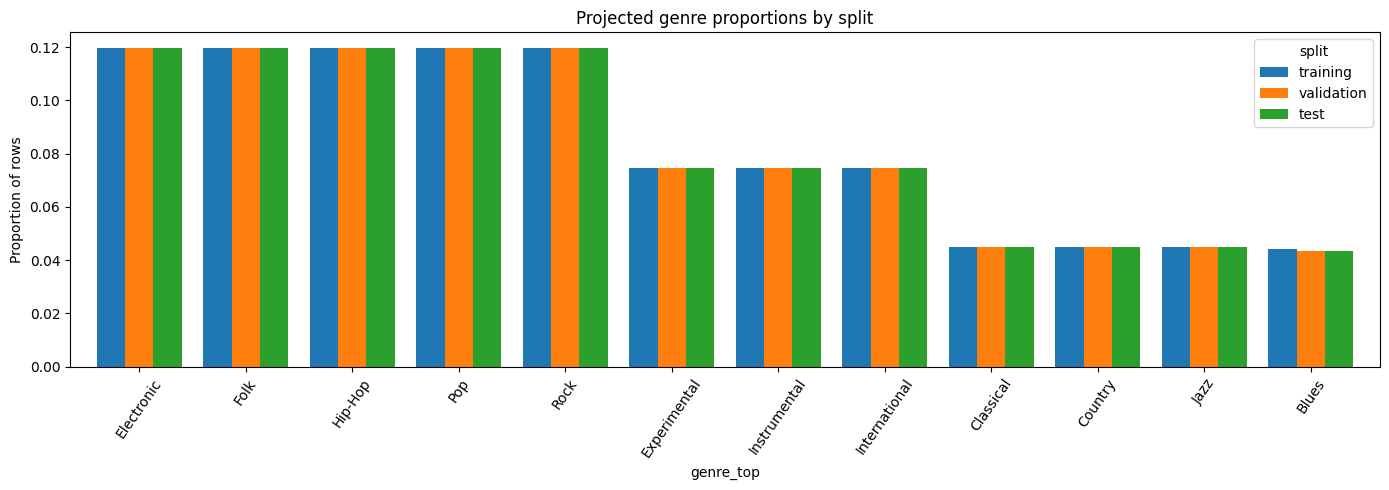

In [ ]:
metrics_table = pd.DataFrame({
    'official_exact_small': split_distance_metrics(official_counts),
    'processed_current': split_distance_metrics(processed_counts),
}).T.round(4)

genre_delta_vs_official = processed_counts.subtract(official_counts, fill_value=0).astype(int)
genre_delta_vs_official['delta_all'] = genre_delta_vs_official.sum(axis=1)
genre_delta_vs_official = genre_delta_vs_official.sort_values('delta_all', ascending=False)

print('Split-distance metrics for official exact-small vs current processed splits:')
display(metrics_table)

print('Per-genre current-minus-official counts:')
display(genre_delta_vs_official[genre_delta_vs_official['delta_all'] != 0])

current_props = proportions_from_counts(processed_counts)
fig, ax = plt.subplots(figsize=(14, 5))
current_props.reindex(plot_genres).plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Current genre proportions by split')
ax.set_ylabel('Proportion of rows')
ax.tick_params(axis='x', rotation=55)
plt.tight_layout()
plt.show()

Official exact-small per-genre totals across train, validation, test, and all:


split,training,validation,test,all
genre_top,,,,
Electronic,800,100,100,1000
Experimental,800,100,100,1000
Folk,800,100,100,1000
Hip-Hop,800,100,100,1000
Instrumental,800,100,100,1000
International,800,100,100,1000
Pop,800,100,100,1000
Rock,800,100,100,1000


Current per-genre totals across train, validation, test, and all:


split,training,validation,test,all
genre_top,,,,
Electronic,1040,130,130,1300
Folk,1040,130,130,1300
Hip-Hop,1040,130,130,1300
Pop,1040,130,130,1300
Rock,1040,130,130,1300
Experimental,800,100,100,1000
Instrumental,800,100,100,1000
International,800,100,100,1000
Classical,240,30,30,300


Projected per-genre totals after materializing the payload:


split,training,validation,test,all
genre_top,,,,
Electronic,1280,160,160,1600
Folk,1280,160,160,1600
Hip-Hop,1280,160,160,1600
Pop,1280,160,160,1600
Rock,1280,160,160,1600
Experimental,800,100,100,1000
Instrumental,800,100,100,1000
International,800,100,100,1000
Classical,480,60,60,600


Official vs current vs projected total rows per genre:


split,training_official,validation_official,test_official,all_official,training_current,validation_current,test_current,all_current,training_projected,validation_projected,test_projected,all_projected,current_minus_official,projected_minus_current,projected_minus_official
genre_top,,,,,,,,,,,,,,,
Electronic,800,100,100,1000,1040,130,130,1300,1280,160,160,1600,300,300,600
Folk,800,100,100,1000,1040,130,130,1300,1280,160,160,1600,300,300,600
Hip-Hop,800,100,100,1000,1040,130,130,1300,1280,160,160,1600,300,300,600
Pop,800,100,100,1000,1040,130,130,1300,1280,160,160,1600,300,300,600
Rock,800,100,100,1000,1040,130,130,1300,1280,160,160,1600,300,300,600
Experimental,800,100,100,1000,800,100,100,1000,800,100,100,1000,0,0,0
Instrumental,800,100,100,1000,800,100,100,1000,800,100,100,1000,0,0,0
International,800,100,100,1000,800,100,100,1000,800,100,100,1000,0,0,0
Classical,0,0,0,0,240,30,30,300,480,60,60,600,300,300,600


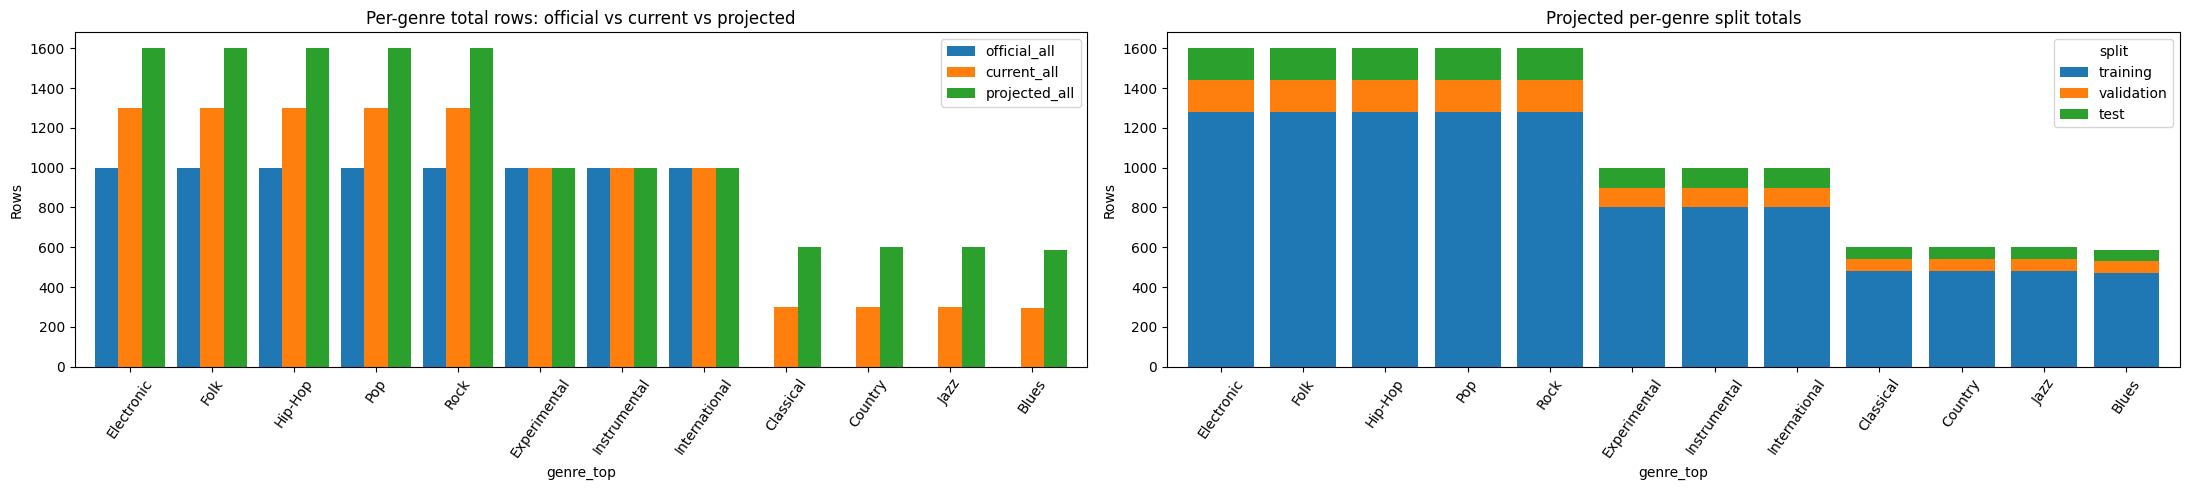

In [ ]:
def add_all_column(counts: pd.DataFrame) -> pd.DataFrame:
    table = counts.reindex(columns=SPLIT_ORDER, fill_value=0).astype(int).copy()
    table['all'] = table.sum(axis=1)
    return table.sort_values('all', ascending=False)


official_genre_totals = add_all_column(official_counts)
current_genre_totals = add_all_column(processed_counts)

official_genre_totals_labeled = official_genre_totals.add_suffix('_official')
current_genre_totals_labeled = current_genre_totals.add_suffix('_current')

genre_totals_compare = official_genre_totals_labeled.join(
    current_genre_totals_labeled,
    how='outer',
).fillna(0).astype(int)

genre_totals_compare['current_minus_official'] = (
    genre_totals_compare['all_current'] - genre_totals_compare['all_official']
    if 'all_official' in genre_totals_compare.columns and 'all_current' in genre_totals_compare.columns
    else 0
)
genre_totals_compare = genre_totals_compare.sort_values(
    ['all_current', 'all_official'],
    ascending=False,
    na_position='last',
)

print('Official exact-small per-genre totals across train, validation, test, and all:')
display(official_genre_totals)

print('Current per-genre totals across train, validation, test, and all:')
display(current_genre_totals)

print('Official vs current total rows per genre:')
display(
    genre_totals_compare[[
        'training_official',
        'validation_official',
        'test_official',
        'all_official',
        'training_current',
        'validation_current',
        'test_current',
        'all_current',
        'current_minus_official',
    ]]
)

plot_totals = pd.DataFrame({
    'official_all': official_genre_totals['all'],
    'current_all': current_genre_totals['all'],
}).fillna(0).astype(int).sort_values('current_all', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

plot_totals.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Per-genre total rows: official vs current')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=55)

current_genre_totals[['training', 'validation', 'test']].plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    width=0.8,
 )
axes[1].set_title('Current per-genre split totals')
axes[1].set_ylabel('Rows')
axes[1].tick_params(axis='x', rotation=55)

plt.tight_layout()
plt.show()

## Interpretation Guide

Use the results in this order:

1. Compare official exact-small against the current processed splits to see whether the saved parquet files still match the original benchmark.
2. Use the payload tables to see which extra samples have already been selected, how many are available per target genre, and which sources they come from.
3. If the current processed splits contain non-FMA sources or genres outside the original 8 exact-small labels, the live split parquets already contain supplemented rows.
4. If the current processed splits still match official exact-small, supplementation has not yet been materialized into the split parquet files even if a payload JSON already exists.
5. Keep using the original notebook for generic split-shape sanity checks. Use this notebook when you need an official-versus-current comparison plus payload provenance.